In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
import numpy as np

CT 1-1:

1: I read and print the first 5 and last 10 entries

2: I take all the dates from the earliest to most recent that can be found in the dataset. I then compare all the dates that exist in that span with the ones that exist in the dataset, filling the gaps with np.nan in the process.

3: The values get sorted

CT 1-2:

1: The plot

           date    AAPL    MSFT   GOOGL    AMZN    TSLA
22   2024-05-07   182.4  409.34  171.25  188.76  177.81
95   2024-05-08  182.74  410.54  169.38   188.0  174.72
33   2024-05-09  184.57  412.32  169.96   189.5  171.97
77   2024-05-10  183.05  414.74  168.65  187.48  168.47
100  2024-05-11     NaN     NaN     NaN     NaN     NaN
..          ...     ...     ...     ...     ...     ...
76   2024-09-23  226.47  433.51  161.85  193.88   250.0
96   2024-09-24  227.37  429.17  162.29  193.96  254.27
20   2024-09-25  226.37  432.11  161.49  192.53  257.02
55   2024-09-26  227.52  431.31  162.73  191.16  254.22
54   2024-09-27  227.79  428.02  163.95  187.97  260.46

[144 rows x 6 columns]


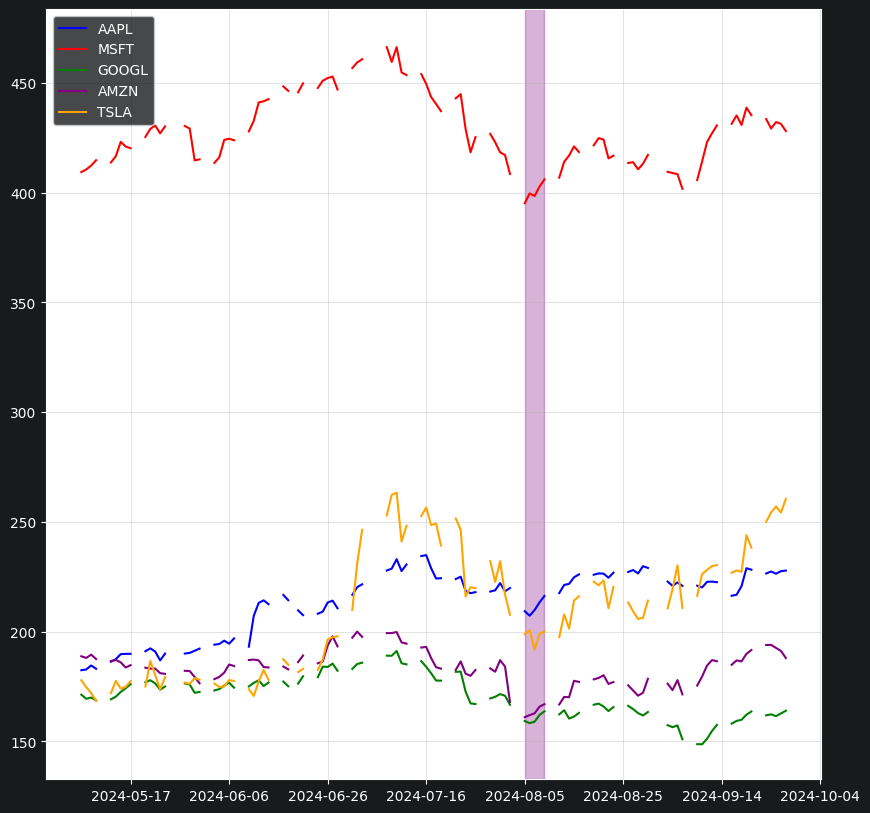

In [48]:
# CT 1-1

# 1
df: pd.DataFrame = pd.read_csv('./data/assignment_CaseA_data.csv')

dfList = [df.iloc[0:5], df.iloc[90:100]]

result: pd.DataFrame = pd.concat(dfList)

# 2

dates = mdates.drange(dt.datetime(2024, 5, 7), dt.datetime(2024, 9, 25), dt.timedelta(days=1))
dates_data = mdates.datestr2num(df['date'])

for date in dates:
    if date not in dates_data:
        df.loc[df.index.max() + 1] = [mdates.num2date(date).strftime('%Y-%m-%d'), np.nan, np.nan, np.nan, np.nan, np.nan]

# 3
df.sort_values(by=['date'], inplace=True)

print(df)

date_data = mdates.datestr2num(df['date'])
aapl_data = df['AAPL']
msft_data = df['MSFT']
googl_data = df['GOOGL']
amzn_data = df['AMZN']
tsla_data = df['TSLA']


#aapl_mask = np.isfinite(aapl_data)
#msft_mask = np.isfinite(msft_data)
#googl_mask = np.isfinite(googl_data)
#amzn_mask = np.isfinite(amzn_data)
#tsla_mask = np.isfinite(tsla_data)

#plt.rcParams["figure.figsize"] = (10, 10)
ax = plt.gca()
ax.set_facecolor('white')
#ax.plot_date(date_data, aapl_data, color='blue', label='AAPL')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.grid()

plt.axvspan(*mdates.datestr2num(['2024-08-05', '2024-08-09']), color='purple', alpha=0.3)
plt.plot(date_data, aapl_data, color='blue', label='AAPL')
plt.plot(date_data, msft_data, color='red', label='MSFT')
plt.plot(date_data, googl_data, color='green', label='GOOGL')
plt.plot(date_data, amzn_data, color='purple', label='AMZN')
plt.plot(date_data, tsla_data, color='orange', label='TSLA')
plt.legend()


plt.savefig('foo.png')